,38 Provinsi,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Persentase Penduduk Miskin (P0) Menurut Provin...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Perkotaan,NaN,NaN,Perdesaan,NaN,NaN,Jumlah,NaN,NaN
2,NaN,2025,NaN,NaN,2025,NaN,NaN,2025,NaN,NaN
3,NaN,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan
4,ACEH,8.54,8.15,-,14.44,14.51,-,12.33,12.22,-


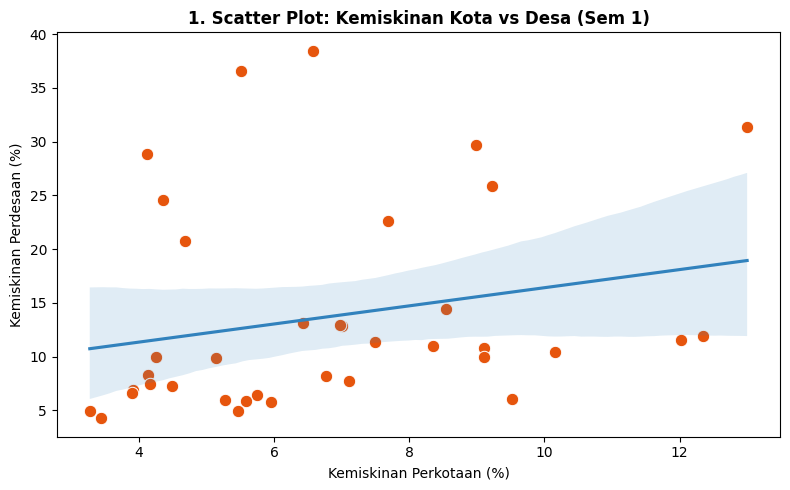

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

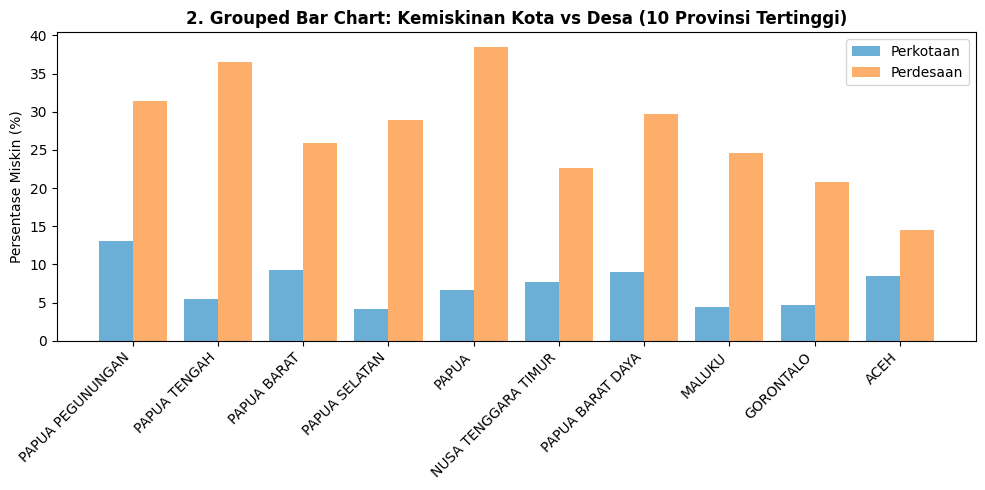

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

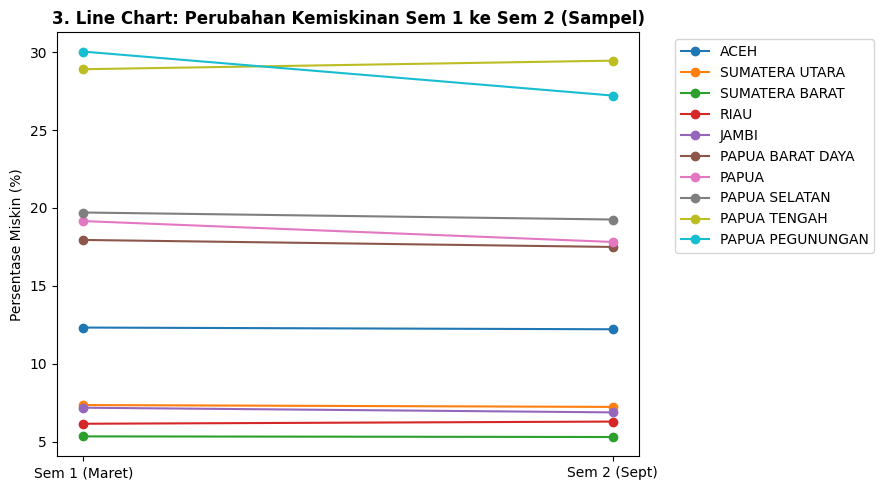

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

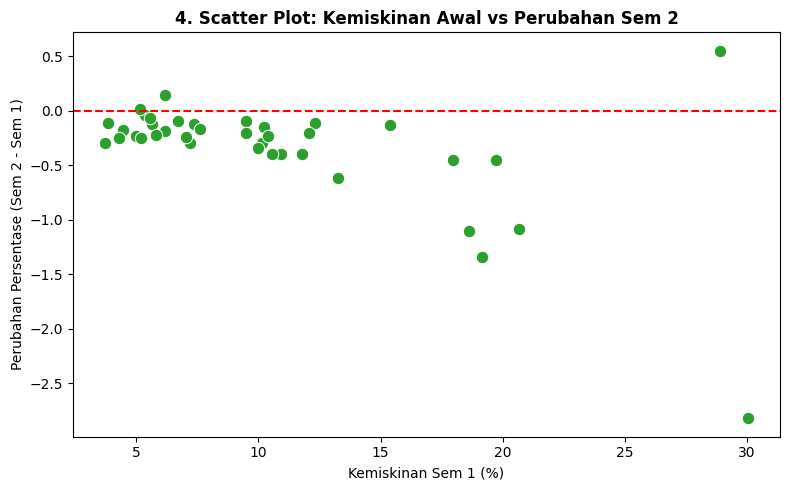

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

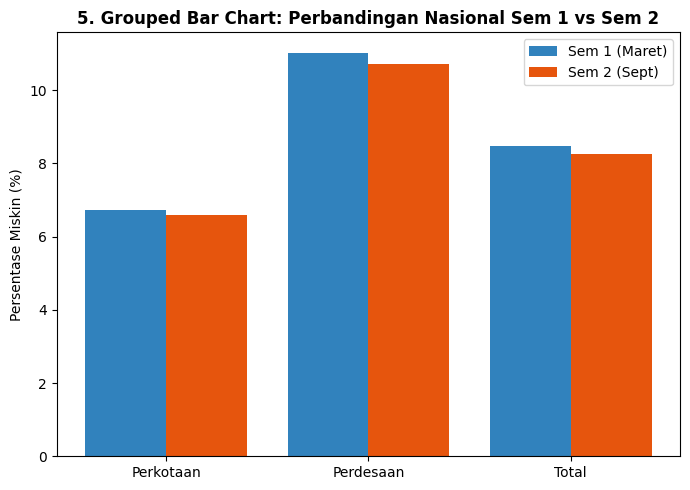

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import files

# 1. Memuat dataset
df = pd.read_csv(
    '/content/Persentase Penduduk Miskin (P0) Menurut Provinsi dan Daerah,'
    ' 2025.csv'
)

# Menampilkan 5 baris pertama DataFrame
display(df.head())

# Cleaning singkat data
df_clean = df.iloc[4:42].copy()
cols_num = [
    'Unnamed: 1',
    'Unnamed: 2',
    'Unnamed: 4',
    'Unnamed: 5',
    'Unnamed: 7',
    'Unnamed: 8',
]
for col in cols_num:
  df_clean[col] = pd.to_numeric(
      df_clean[col].astype(str).str.replace('-', ''), errors='coerce'
  )

df_clean['Provinsi'] = df_clean['38 Provinsi'].str.strip()
df_clean['Perubahan'] = df_clean['Unnamed: 8'] - df_clean['Unnamed: 7']

# ---------------------------------------------------------
# VISUALISASI 1: Scatter Plot (Kota vs Desa)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean, x='Unnamed: 1', y='Unnamed: 4', color='#e6550d', s=80
)
sns.regplot(
    data=df_clean, x='Unnamed: 1', y='Unnamed: 4', scatter=False, color='#3182bd'
)
plt.title('1. Scatter Plot: Kemiskinan Kota vs Desa (Sem 1)', fontweight='bold')
plt.xlabel('Kemiskinan Perkotaan (%)')
plt.ylabel('Kemiskinan Perdesaan (%)')
plt.tight_layout()
plt.savefig('chart1_scatter_kota_desa.png', dpi=300)
plt.show()
files.download('chart1_scatter_kota_desa.png')

# ---------------------------------------------------------
# VISUALISASI 2: Grouped Bar Chart (Top 10 Provinsi)
# ---------------------------------------------------------
top10 = df_clean.sort_values(by='Unnamed: 7', ascending=False).head(10)
plt.figure(figsize=(10, 5))
x = range(len(top10))
plt.bar(
    [i - 0.2 for i in x],
    top10['Unnamed: 1'],
    width=0.4,
    label='Perkotaan',
    color='#6baed6',
)
plt.bar(
    [i + 0.2 for i in x],
    top10['Unnamed: 4'],
    width=0.4,
    label='Perdesaan',
    color='#fdae6b',
)
plt.xticks(x, top10['Provinsi'], rotation=45, ha='right')
plt.title(
    '2. Grouped Bar Chart: Kemiskinan Kota vs Desa (10 Provinsi Tertinggi)',
    fontweight='bold',
)
plt.ylabel('Persentase Miskin (%)')
plt.legend()
plt.tight_layout()
plt.savefig('chart2_grouped_bar_top10.png', dpi=300)
plt.show()
files.download('chart2_grouped_bar_top10.png')

# ---------------------------------------------------------
# VISUALISASI 3: Line Chart (Perubahan Sem 1 ke Sem 2)
# ---------------------------------------------------------
sample_prov = pd.concat([df_clean.head(5), df_clean.tail(5)])
plt.figure(figsize=(9, 5))
for _, r in sample_prov.iterrows():
  plt.plot(
      ['Sem 1 (Maret)', 'Sem 2 (Sept)'],
      [r['Unnamed: 7'], r['Unnamed: 8']],
      marker='o',
      label=r['Provinsi'],
  )
plt.title(
    '3. Line Chart: Perubahan Kemiskinan Sem 1 ke Sem 2 (Sampel)',
    fontweight='bold',
)
plt.ylabel('Persentase Miskin (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart3_line_perubahan_semester.png', dpi=300)
plt.show()
files.download('chart3_line_perubahan_semester.png')

# ---------------------------------------------------------
# VISUALISASI 4: Scatter Plot (Kemiskinan Awal vs Perubahan)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean, x='Unnamed: 7', y='Perubahan', color='#2ca02c', s=80
)
plt.axhline(0, color='red', linestyle='--')
plt.title(
    '4. Scatter Plot: Kemiskinan Awal vs Perubahan Sem 2', fontweight='bold'
)
plt.xlabel('Kemiskinan Sem 1 (%)')
plt.ylabel('Perubahan Persentase (Sem 2 - Sem 1)')
plt.tight_layout()
plt.savefig('chart4_scatter_awal_vs_perubahan.png', dpi=300)
plt.show()
files.download('chart4_scatter_awal_vs_perubahan.png')

# ---------------------------------------------------------
# VISUALISASI 5: Grouped Bar Chart (Agregat Nasional)
# ---------------------------------------------------------
indo_s1 = [
    float(df.iloc[42]['Unnamed: 1']),
    float(df.iloc[42]['Unnamed: 4']),
    float(df.iloc[42]['Unnamed: 7']),
]
indo_s2 = [
    float(df.iloc[42]['Unnamed: 2']),
    float(df.iloc[42]['Unnamed: 5']),
    float(df.iloc[42]['Unnamed: 8']),
]
categories = ['Perkotaan', 'Perdesaan', 'Total']

plt.figure(figsize=(7, 5))
x_i = range(len(categories))
plt.bar(
    [i - 0.2 for i in x_i],
    indo_s1,
    width=0.4,
    label='Sem 1 (Maret)',
    color='#3182bd',
)
plt.bar(
    [i + 0.2 for i in x_i],
    indo_s2,
    width=0.4,
    label='Sem 2 (Sept)',
    color='#e6550d',
)
plt.xticks(x_i, categories)
plt.title(
    '5. Grouped Bar Chart: Perbandingan Nasional Sem 1 vs Sem 2',
    fontweight='bold',
)
plt.ylabel('Persentase Miskin (%)')
plt.legend()
plt.tight_layout()
plt.savefig('chart5_bar_nasional.png', dpi=300)
plt.show()
files.download('chart5_bar_nasional.png')